In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Parametry przestrzenne
dx = 0.05
x_internal = np.arange(dx, 1.0, dx) # Węzły wewnętrzne: od 0.05 do 0.95 (19 punktów)
N = len(x_internal)

# 1. Warunek początkowy y(0) dla węzłów wewnętrznych
y0 = np.where(x_internal <= 0.5, 2 * x_internal, 2 - 2 * x_internal)

# 2. Budowa macierzy A (Laplasjan w 1D)
main_diag = -2.0 * np.ones(N)
off_diag = 1.0 * np.ones(N - 1)
A = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
A = A / (dx**2)

# 3. Definicja układu równań różniczkowych y' = A*y
def heat_ode(t, y):
    return A.dot(y)

# 4. Rozwiązanie układu (używamy solwera dla równań sztywnych: 'BDF' lub 'Radau')
t_span = (0.0, 0.06)
# Zapisujemy wyniki co 0.001, aby móc narysować gładki wykres (61 punktów czasowych)
t_eval = np.linspace(0.0, 0.06, 61)

sol = solve_ivp(heat_ode, t_span, y0, method='BDF', t_eval=t_eval)

# 5. Przygotowanie danych do wykresu (dodanie brzegów x=0 i x=1, gdzie u=0)
t_out = sol.t
y_out_internal = sol.y # Wymiary: (19 węzłów, 61 chwil czasowych)

# Dodajemy zera na górze i dole macierzy (warunki brzegowe u(t,0)=0, u(t,1)=0)
zeros_boundary = np.zeros((1, len(t_out)))
u_full = np.vstack((zeros_boundary, y_out_internal, zeros_boundary))
x_full = np.arange(0.0, 1.0 + dx, dx)


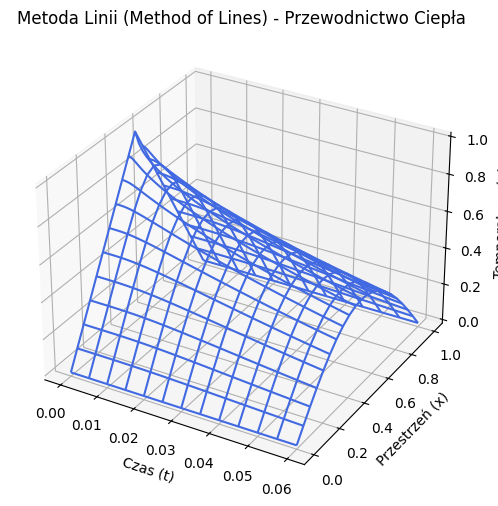

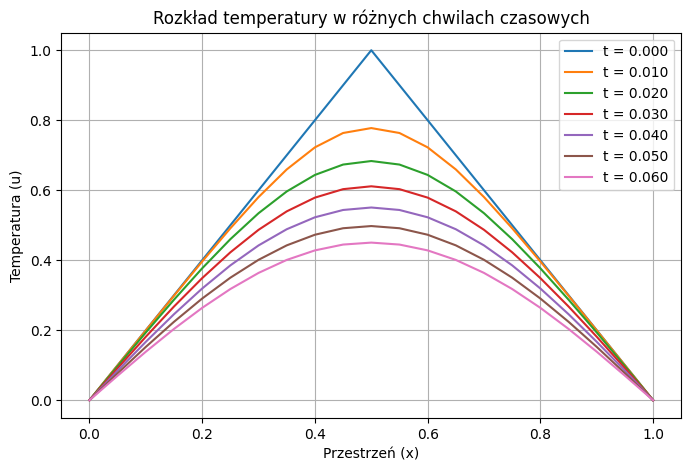

In [7]:

# 6. Rysowanie wykresu 3D (Wireframe)
T, X = np.meshgrid(t_out, x_full)

fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_wireframe(T, X, u_full, color='royalblue', rstride=1, cstride=5)

ax.set_title("Metoda Linii (Method of Lines) - Przewodnictwo Ciepła")
ax.set_xlabel("Czas (t)")
ax.set_ylabel("Przestrzeń (x)")
ax.set_zlabel("Temperatura (u)")
plt.show()

# Alternatywny wykres 2D (linie dla wybranych chwil czasowych)
plt.figure(figsize=(8, 5))
for i in range(0, len(t_out), 10): # Rysuj co 10 krok (co 0.01 sekundy)
    plt.plot(x_full, u_full[:, i], label=f't = {t_out[i]:.3f}')
plt.title("Rozkład temperatury w różnych chwilach czasowych")
plt.xlabel("Przestrzeń (x)")
plt.ylabel("Temperatura (u)")
plt.legend()
plt.grid(True)
plt.show()